# Pipeline 3 — Live Run Analysis

Standalone analysis notebook for any `run_pipeline.py` output (SimConnect live or file mode).

**Usage**: Set `RUN_DIR` in Cell 1 to your run directory, then **Kernel → Restart and Run All**.

No other notebooks need to be open — this is fully self-contained.

| Cell | Content | Requires |
|------|---------|---------|
| 1  | Setup & load `results.csv` | — |
| 2  | Summary metrics table | — |
| 3  | Error over time | — |
| 4  | Trajectory map | — |
| 5  | Gate health (CShape + inliers) | — |
| 6  | EKF position sigma (convergence) | — |
| 7  | Error CDF | — |
| 8  | Timing & performance | — |
| 9  | **Multi-method comparison table** (Online EKF / Homo raw / Homo corrected) | — |
| 10 | **Per-frame diagnostic table** + best/worst visual measurements | — |
| 11 | **Turn impact analysis** (roll > 15°) | — |
| 12 | **In-map / out-of-map breakdown** | — |
| 13 | **Particle filter health + camera look-ahead calibration** | `SAVE_ANALYSIS_DATA=True` |
| 14 | **Per-component timing breakdown** (stacked bar + latency) | `SAVE_TIMING_DATA=True` |
| 15 | **Trajectory GIF animation** | `pip install imageio` |

Cells 9–12 and 15 work from `results.csv` alone (no extra flags).
Cell 13 requires `analysis_extras.csv` produced with `config.SAVE_ANALYSIS_DATA = True`.
Cell 14 requires `timing_data.csv` produced with `config.SAVE_TIMING_DATA = True`.

In [46]:
from pathlib import Path
import json, math, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
from config import config
from src.tile_utils import haversine_distance as _hav

# ── CONFIGURE HERE ──────────────────────────────────────────────────────────
RUN_DIR   = Path(r"C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\runs\live_025_Odense_without_Pipeline_trace")   # ← change to your run directory
SAVE_FIGS = True   # save PNGs to outputs/analysis/<run_id>/
# ────────────────────────────────────────────────────────────────────────────

results = pd.read_csv(RUN_DIR / "results.csv")
meta    = json.loads((RUN_DIR / "run_meta.json").read_text()) \
          if (RUN_DIR / "run_meta.json").exists() else {}

have_gt = results["gps_lat"].notna() & results["gps_lon"].notna()
results["online_err_m"] = [
    _hav(r.final_lat, r.final_lon, r.gps_lat, r.gps_lon)
    if have_gt.iloc[i] else np.nan
    for i, (_, r) in enumerate(results.iterrows())
]
gate = results["gate_pass"].astype(bool)

OUT_DIR = config.ANALYSIS_OUTPUT_DIR / RUN_DIR.name
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run:     {meta.get('run_id', RUN_DIR.name)}")
print(f"Source:  {meta.get('source', 'unknown')}  |  Frames: {len(results)}")
print(f"GT:      {have_gt.sum()}/{len(results)} frames  |  Gate passes: {gate.sum()} ({gate.mean()*100:.0f}%)")

Run:     live_025_Odense_without_Pipeline_trace
Source:  simconnect  |  Frames: 119
GT:      119/119 frames  |  Gate passes: 116 (97%)


In [47]:
errs = results["online_err_m"].dropna()
print(f"\n{'─'*40}")
print(f"  Online EKF accuracy  (n={len(errs)})")
print(f"{'─'*40}")
if len(errs):
    for label, val in [
        ("mean",   np.mean(errs)),
        ("median", np.median(errs)),
        ("min",    np.min(errs)),
        ("max",    np.max(errs)),
        ("std",    np.std(errs)),
    ]:
        print(f"  {label:<8s} {val:8.1f} m")
    print()
    for thresh in [10, 25, 50, 100, 250]:
        pct = np.mean(errs <= thresh) * 100
        bar = "\u2588" * int(pct / 5)
        print(f"  <{thresh:4d}m  {pct:5.1f}%  {bar}")
else:
    print("  (no GT — SimConnect GPS not available in this run)")
print(f"{'─'*40}")
elapsed = meta.get("elapsed_s", 0)
fps     = meta.get("fps", 0)
if fps:
    print(f"  Elapsed: {elapsed:.1f}s  |  FPS: {fps:.3f}  |  s/frame: {1/fps:.2f}")


────────────────────────────────────────
  Online EKF accuracy  (n=119)
────────────────────────────────────────
  mean         75.6 m
  median       71.9 m
  min           7.1 m
  max         222.1 m
  std          52.0 m

  <  10m    4.2%  
  <  25m   21.0%  ████
  <  50m   41.2%  ████████
  < 100m   69.7%  █████████████
  < 250m  100.0%  ████████████████████
────────────────────────────────────────
  Elapsed: 307.9s  |  FPS: 0.387  |  s/frame: 2.58


Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/error_over_time.png


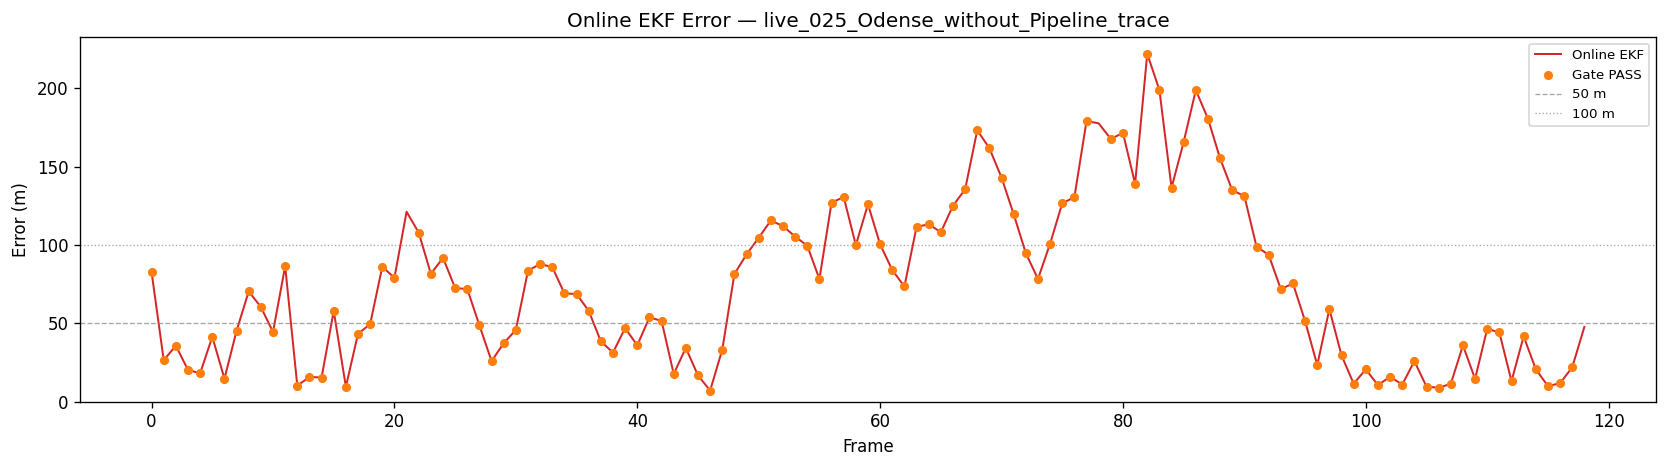

In [48]:
fig, ax = plt.subplots(figsize=(14, 4))
xs = results["frame_idx"]
ax.plot(xs, results["online_err_m"], color="tab:red", lw=1.2, label="Online EKF")
ax.scatter(xs[gate], results["online_err_m"][gate], s=20, color="tab:orange",
           zorder=5, label="Gate PASS")
ax.axhline(50,  color="gray", lw=0.8, ls="--", alpha=0.7, label="50 m")
ax.axhline(100, color="gray", lw=0.8, ls=":",  alpha=0.7, label="100 m")
ax.set_xlabel("Frame")
ax.set_ylabel("Error (m)")
ax.set_title(f"Online EKF Error — {meta.get('run_id', RUN_DIR.name)}")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "error_over_time.png")
    print(f"Saved → {OUT_DIR}/error_over_time.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/trajectory_map.png


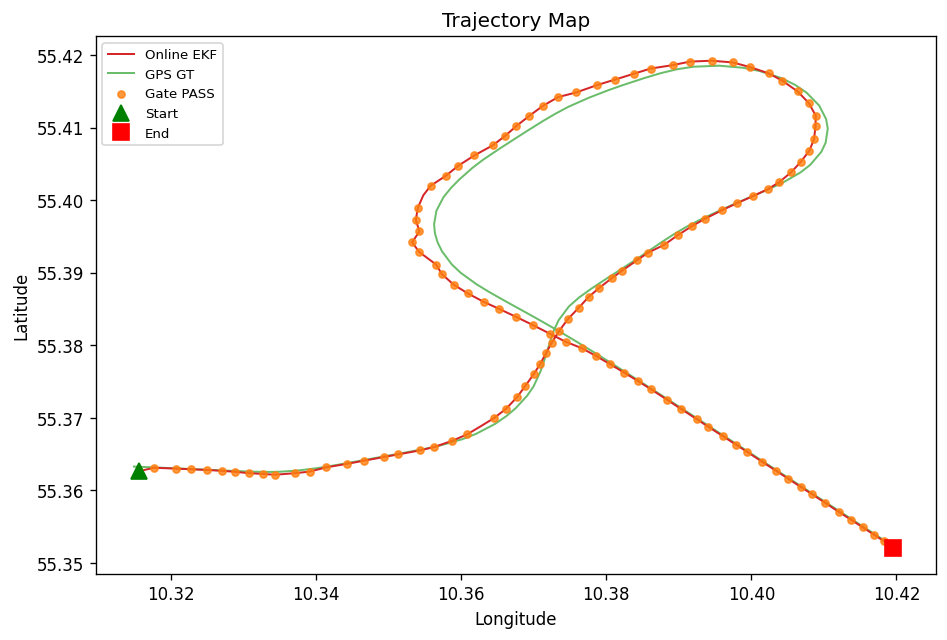

In [49]:
fig, ax = plt.subplots(figsize=(8, 8))
gt_valid = results[have_gt]
ax.plot(results["final_lon"], results["final_lat"],
        color="tab:red", lw=1.2, label="Online EKF", zorder=3)
if len(gt_valid):
    ax.plot(gt_valid["gps_lon"], gt_valid["gps_lat"],
            color="tab:green", lw=1.2, alpha=0.7, label="GPS GT", zorder=2)
gate_rows = results[gate]
ax.scatter(gate_rows["final_lon"], gate_rows["final_lat"],
           s=18, c="tab:orange", zorder=5, label="Gate PASS", alpha=0.8)
ax.plot(results["final_lon"].iloc[0], results["final_lat"].iloc[0],
        "g^", ms=10, zorder=6, label="Start")
ax.plot(results["final_lon"].iloc[-1], results["final_lat"].iloc[-1],
        "rs", ms=10, zorder=6, label="End")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Trajectory Map")
ax.legend(fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "trajectory_map.png")
    print(f"Saved → {OUT_DIR}/trajectory_map.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/gate_health.png


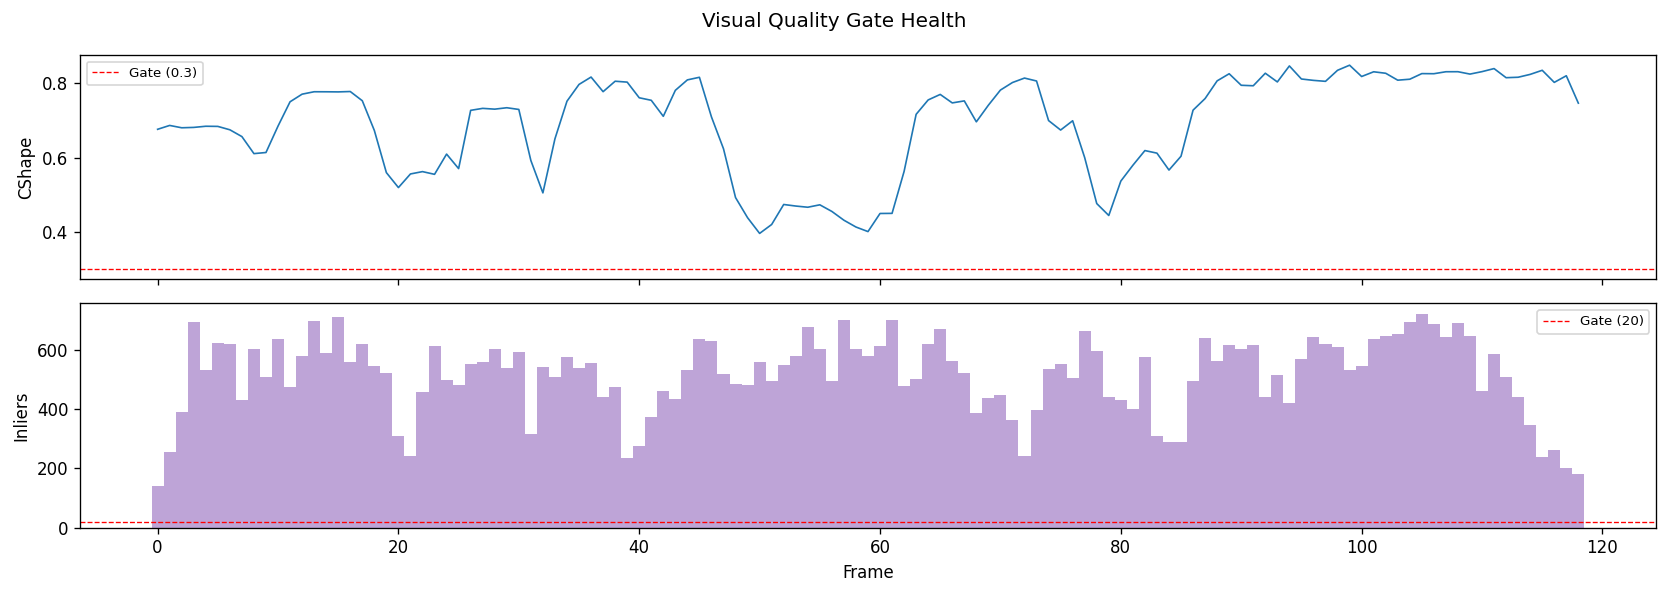

In [50]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
xs = results["frame_idx"]
ax1.plot(xs, results["cs_shape"], color="tab:blue", lw=1)
ax1.axhline(config.QUALITY_GATE_CSHAPE, color="red", ls="--", lw=0.8,
            label=f"Gate ({config.QUALITY_GATE_CSHAPE})")
ax1.set_ylabel("CShape")
ax1.legend(fontsize=8)
ax2.bar(xs, results["inliers"], color="tab:purple", alpha=0.6, width=1)
ax2.axhline(config.QUALITY_GATE_INLIERS, color="red", ls="--", lw=0.8,
            label=f"Gate ({config.QUALITY_GATE_INLIERS})")
ax2.set_ylabel("Inliers")
ax2.set_xlabel("Frame")
ax2.legend(fontsize=8)
plt.suptitle("Visual Quality Gate Health")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "gate_health.png")
    print(f"Saved → {OUT_DIR}/gate_health.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/ekf_sigma.png


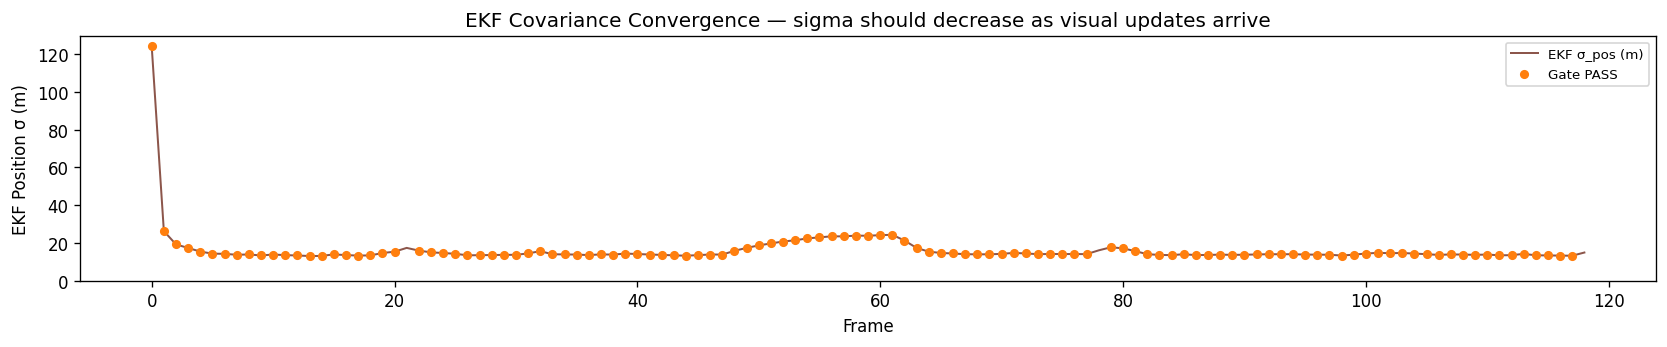

In [51]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(results["frame_idx"], results["ekf_pos_sigma"],
        color="tab:brown", lw=1.2, label="EKF \u03c3_pos (m)")
ax.scatter(results["frame_idx"][gate], results["ekf_pos_sigma"][gate],
           s=20, color="tab:orange", zorder=5, label="Gate PASS")
ax.set_xlabel("Frame")
ax.set_ylabel("EKF Position \u03c3 (m)")
ax.set_title("EKF Covariance Convergence — sigma should decrease as visual updates arrive")
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "ekf_sigma.png")
    print(f"Saved → {OUT_DIR}/ekf_sigma.png")
plt.show()

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/error_cdf.png


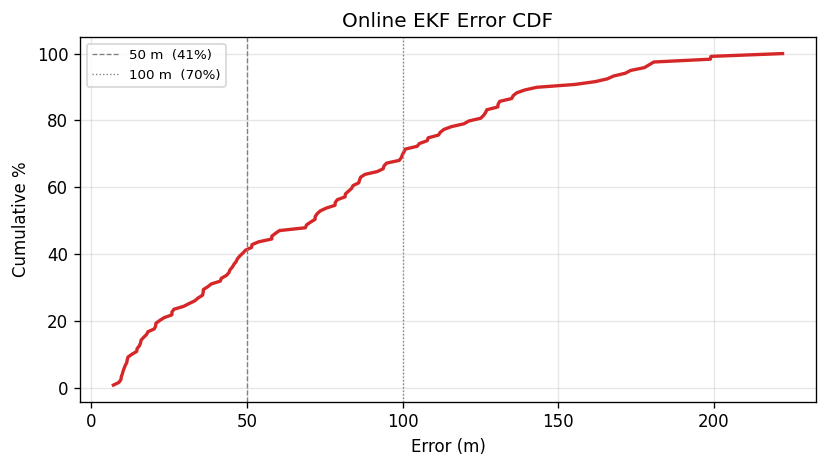

In [52]:
errs_sorted = results["online_err_m"].dropna().sort_values()
if len(errs_sorted):
    fig, ax = plt.subplots(figsize=(7, 4))
    cdf = np.arange(1, len(errs_sorted) + 1) / len(errs_sorted)
    ax.plot(errs_sorted, cdf * 100, color="tab:red", lw=2)
    for thresh, ls in [(50, "--"), (100, ":")]:
        pct_at = float(np.mean(errs_sorted <= thresh) * 100)
        ax.axvline(thresh, color="gray", ls=ls, lw=0.8,
                   label=f"{thresh} m  ({pct_at:.0f}%)")
    ax.set_xlabel("Error (m)")
    ax.set_ylabel("Cumulative %")
    ax.set_title("Online EKF Error CDF")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(OUT_DIR / "error_cdf.png")
        print(f"Saved → {OUT_DIR}/error_cdf.png")
    plt.show()
else:
    print("No GT data available — CDF skipped")

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/timing.png


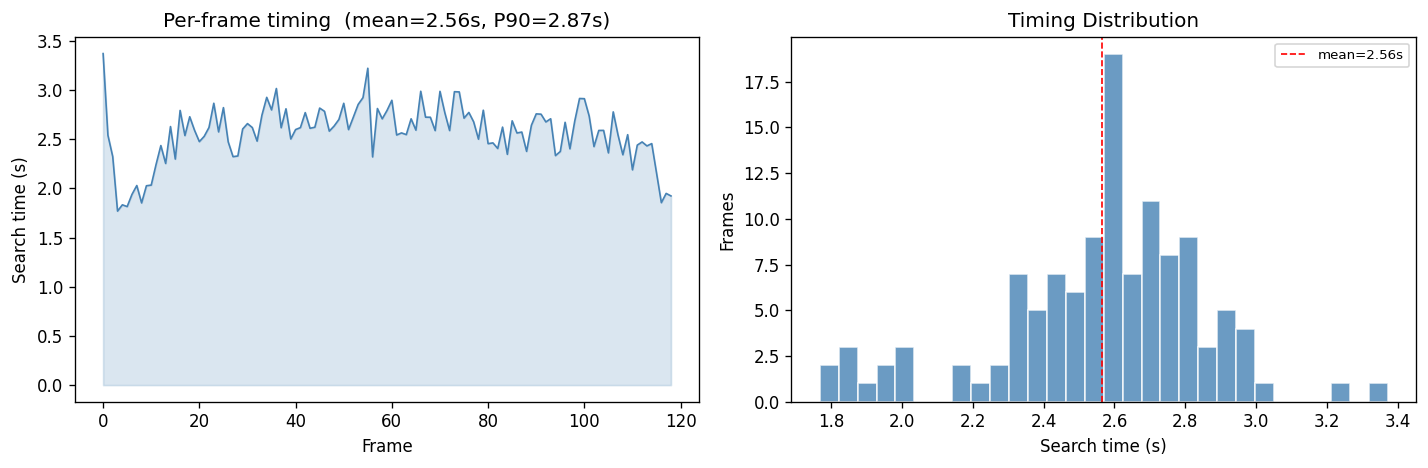


Tiles tested — mean: 6.9  max: 9
Verification matches — mean: 587.0

End-to-end latency (frame capture → GPS estimate):
  mean=3027ms  median=3059ms  P90=3466ms  max=3843ms


In [53]:
st = results["search_time_s"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(results["frame_idx"], st, color="steelblue", lw=1)
ax1.fill_between(results["frame_idx"], st, alpha=0.2, color="steelblue")
ax1.set_xlabel("Frame")
ax1.set_ylabel("Search time (s)")
ax1.set_title(f"Per-frame timing  (mean={st.mean():.2f}s, P90={st.quantile(0.9):.2f}s)")
ax2.hist(st, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(st.mean(), color="red", ls="--", lw=1, label=f"mean={st.mean():.2f}s")
ax2.set_xlabel("Search time (s)")
ax2.set_ylabel("Frames")
ax2.legend(fontsize=8)
ax2.set_title("Timing Distribution")
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(OUT_DIR / "timing.png")
    print(f"Saved → {OUT_DIR}/timing.png")
plt.show()
print(f"\nTiles tested — mean: {results['tiles_tested'].mean():.1f}  max: {results['tiles_tested'].max()}")
print(f"Verification matches — mean: {results['verification_matches'].mean():.1f}")
if "inference_ms" in results.columns and results["inference_ms"].notna().any():
    inf = results["inference_ms"].dropna()
    print(f"\nEnd-to-end latency (frame capture → GPS estimate):")
    print(f"  mean={inf.mean():.0f}ms  median={inf.median():.0f}ms  P90={inf.quantile(0.9):.0f}ms  max={inf.max():.0f}ms")

In [54]:
# Cell 9 — Multi-Method Comparison Table
# Works from results.csv alone — no extra flags needed.
from collections import Counter

def _safe_hav(lat1, lon1, lat2, lon2):
    if any(v is None or (isinstance(v, float) and math.isnan(v))
           for v in [lat1, lon1, lat2, lon2]):
        return np.nan
    return _hav(lat1, lon1, lat2, lon2)

results["homo_raw_err"]  = [_safe_hav(r.homo_lat, r.homo_lon, r.gps_lat, r.gps_lon)
                             for _, r in results.iterrows()]
results["homo_corr_err"] = [_safe_hav(r.homo_corrected_lat, r.homo_corrected_lon,
                                       r.gps_lat, r.gps_lon)
                             for _, r in results.iterrows()]

methods = {
    "Online EKF  (visual+IMU)": results["online_err_m"],
    "Homo raw    (uncorrected)": results["homo_raw_err"],
    "Homo corr   (look-ahead) ": results["homo_corr_err"],
}
thresholds = [10, 25, 50, 100, 200]

print(f"\n{'='*100}")
print(f"  MULTI-METHOD COMPARISON  —  {meta.get('run_id', RUN_DIR.name)}  ({len(results)} frames)")
print(f"{'='*100}")
print(f"  {'Method':<28s} | {'n':>4s} {'mean':>7s} {'med':>7s} {'std':>7s} {'max':>7s}"
      f" | {'<10m':>6s} {'<25m':>6s} {'<50m':>6s} {'<100m':>6s} {'<200m':>6s}")
print(f"  {'-'*96}")
for lbl, v_series in methods.items():
    v = v_series.dropna().values
    if len(v) == 0:
        print(f"  {lbl:<28s} | (no data)")
        continue
    pcts = "  ".join(f"{(v < t).mean()*100:5.1f}%" for t in thresholds)
    print(f"  {lbl:<28s} | {len(v):4d} {np.mean(v):7.1f} {np.median(v):7.1f}"
          f" {np.std(v):7.1f} {np.max(v):7.0f} | {pcts}")

# Percentile table
print(f"\n  {'Percentile':<28s} | {'P50':>8s} {'P75':>8s} {'P90':>8s} {'P95':>8s} {'P99':>8s}")
print(f"  {'-'*72}")
for lbl, v_series in methods.items():
    v = v_series.dropna().values
    if len(v) == 0: continue
    ps = [np.percentile(v, p) for p in [50, 75, 90, 95, 99]]
    print(f"  {lbl:<28s} | {ps[0]:8.1f} {ps[1]:8.1f} {ps[2]:8.1f} {ps[3]:8.1f} {ps[4]:8.1f}")

# Improvement vs Online EKF
online_v = results["online_err_m"].dropna()
print(f"\n  Gate pass rate: {gate.sum()}/{len(results)} ({gate.mean()*100:.0f}%)")
print(f"  Method distribution: {dict(Counter(results['method']))}")
if len(online_v):
    beats_raw  = (results["online_err_m"] < results["homo_raw_err"]).sum()
    beats_corr = (results["online_err_m"] < results["homo_corr_err"]).sum()
    print(f"  Online EKF beats homo-raw on {beats_raw}/{len(results)} frames")
    print(f"  Online EKF beats homo-corr on {beats_corr}/{len(results)} frames")


  MULTI-METHOD COMPARISON  —  live_025_Odense_without_Pipeline_trace  (119 frames)
  Method                       |    n    mean     med     std     max |   <10m   <25m   <50m  <100m  <200m
  ------------------------------------------------------------------------------------------------
  Online EKF  (visual+IMU)     |  119    75.6    71.9    52.0     222 |   4.2%   21.0%   41.2%   69.7%   99.2%
  Homo raw    (uncorrected)    |  119   147.1   119.4    88.2     528 |   0.8%    0.8%    6.7%   28.6%   79.0%
  Homo corr   (look-ahead)     |  119    87.9    58.6    92.1     499 |  13.4%   31.9%   45.4%   66.4%   90.8%

  Percentile                   |      P50      P75      P90      P95      P99
  ------------------------------------------------------------------------
  Online EKF  (visual+IMU)     |     71.9    109.9    145.6    173.7    199.1
  Homo raw    (uncorrected)    |    119.4    183.2    246.1    324.5    424.1
  Homo corr   (look-ahead)     |     58.6    135.1    194.2    304.

In [55]:
# Cell 10 — Per-Frame Diagnostic Table + Best/Worst Visual Measurements
# Works from results.csv alone.

df_diag = results[[
    "frame_idx", "online_err_m", "homo_corr_err", "cs_shape", "inliers",
    "gate_pass", "method", "semantic_conf", "tiles_tested", "search_time_s",
]].copy()
df_diag["gate_pass"] = df_diag["gate_pass"].astype(bool)

# Worst-error frames
print("Worst 20 frames by Online EKF error:")
print(f"  {'F':>4s} | {'online':>7s} | {'homo_c':>7s} | {'CS':>6s} | {'inl':>5s}"
      f" | {'gate':>4s} | {'method':<20s} | {'sem':>5s}")
print(f"  {'-'*80}")
for _, r in df_diag.nlargest(20, "online_err_m").iterrows():
    hc = f"{r.homo_corr_err:6.0f}m" if not np.isnan(r.homo_corr_err) else "   N/A"
    print(f"  F{int(r.frame_idx):3d} | {r.online_err_m:6.0f}m | {hc} | "
          f"{r.cs_shape:6.3f} | {int(r.inliers):5d} | {'Y' if r.gate_pass else 'N':>4s}"
          f" | {r.method:<20s} | {r.semantic_conf:.3f}")

# Best/worst visual measurements (by homo_corr_err)
homo_valid = df_diag.dropna(subset=["homo_corr_err"])
if len(homo_valid):
    print(f"\nBest 10 visual measurements (lowest homo_corr_err):")
    print(f"  {'F':>4s} | {'homo_c':>7s} | {'CS':>6s} | {'inl':>5s} | {'gate':>4s} | {'online':>7s}")
    print(f"  {'-'*52}")
    for _, r in homo_valid.nsmallest(10, "homo_corr_err").iterrows():
        print(f"  F{int(r.frame_idx):3d} | {r.homo_corr_err:6.0f}m | {r.cs_shape:6.3f}"
              f" | {int(r.inliers):5d} | {'Y' if r.gate_pass else 'N':>4s} | {r.online_err_m:6.0f}m")

    print(f"\nWorst 10 visual measurements (highest homo_corr_err):")
    print(f"  {'F':>4s} | {'homo_c':>7s} | {'CS':>6s} | {'inl':>5s} | {'gate':>4s} | {'online':>7s}")
    print(f"  {'-'*52}")
    for _, r in homo_valid.nlargest(10, "homo_corr_err").iterrows():
        print(f"  F{int(r.frame_idx):3d} | {r.homo_corr_err:6.0f}m | {r.cs_shape:6.3f}"
              f" | {int(r.inliers):5d} | {'Y' if r.gate_pass else 'N':>4s} | {r.online_err_m:6.0f}m")
else:
    print("(No homo_corr_err data — no GT or no gate passes)")

Worst 20 frames by Online EKF error:
     F |  online |  homo_c |     CS |   inl | gate | method               |   sem
  --------------------------------------------------------------------------------
  F 82 |    222m |    386m |  0.619 |   578 |    Y | temporal_tracking    | 0.922
  F 83 |    199m |    141m |  0.612 |   310 |    Y | temporal_tracking    | 0.802
  F 86 |    199m |    193m |  0.728 |   497 |    Y | temporal_tracking    | 0.897
  F 87 |    181m |     94m |  0.759 |   642 |    Y | temporal_tracking    | 0.779
  F 77 |    179m |    306m |  0.600 |   664 |    Y | temporal_tracking    | 0.775
  F 78 |    178m |    499m |  0.477 |   596 |    N | temporal_tracking    | 0.771
  F 68 |    173m |    293m |  0.696 |   389 |    Y | temporal_tracking    | 0.795
  F 80 |    172m |    177m |  0.537 |   431 |    Y | temporal_tracking    | 0.866
  F 79 |    168m |    156m |  0.445 |   443 |    Y | temporal_tracking    | 0.803
  F 85 |    166m |    307m |  0.604 |   290 |    Y | tempora

Turn analysis  (threshold: |roll| > 15.0°)
  Straight frames: 87   Turn frames: 32

  Straight (87 frames):
    Gate pass:      85/87 (98%)
    Online EKF err: mean=69.7m  median=51.6m  max=222m
    Homo corr err:  mean=78.8m  median=38.3m

  Turning (32 frames):
    Gate pass:      31/32 (97%)
    Online EKF err: mean=91.6m  median=91.0m  max=181m
    Homo corr err:  mean=112.6m  median=99.8m

Saved → C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace/turn_impact.png


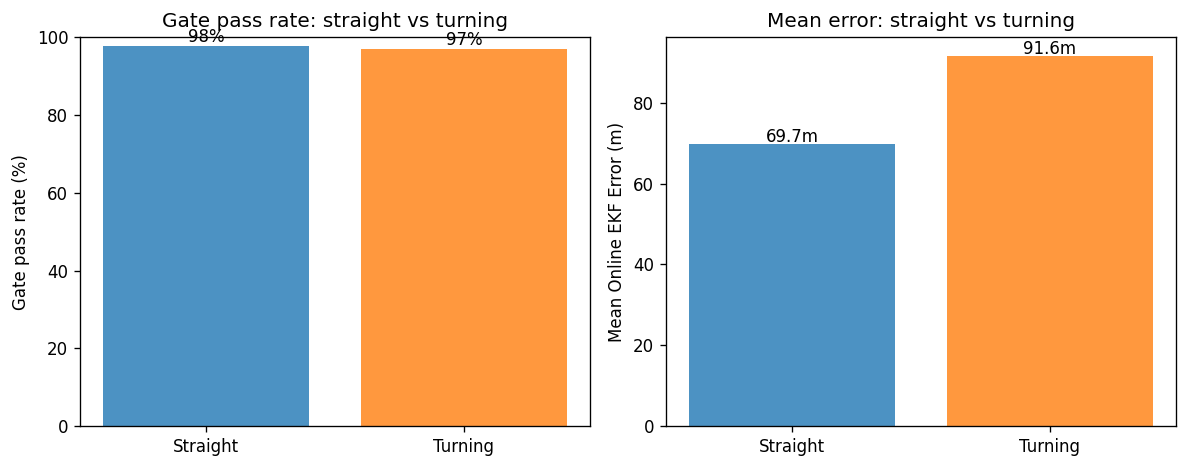

In [56]:
# Cell 11 — Turn Impact Analysis (roll_deg > 15°)
# Works from results.csv alone.

TURN_THRESH_DEG = 15.0
turn_mask    = results["roll_deg"].abs() > TURN_THRESH_DEG
straight     = results[~turn_mask]
turning      = results[turn_mask]

print(f"Turn analysis  (threshold: |roll| > {TURN_THRESH_DEG}°)")
print(f"  Straight frames: {len(straight)}   Turn frames: {len(turning)}")
print()

for label, subset in [("Straight", straight), ("Turning", turning)]:
    if len(subset) == 0:
        print(f"  {label}: no frames"); continue
    g = subset["gate_pass"].astype(bool)
    errs = subset["online_err_m"].dropna()
    h_errs = subset["homo_corr_err"].dropna()
    print(f"  {label} ({len(subset)} frames):")
    print(f"    Gate pass:      {g.sum()}/{len(subset)} ({g.mean()*100:.0f}%)")
    if len(errs):
        print(f"    Online EKF err: mean={errs.mean():.1f}m  median={errs.median():.1f}m  max={errs.max():.0f}m")
    if len(h_errs):
        print(f"    Homo corr err:  mean={h_errs.mean():.1f}m  median={h_errs.median():.1f}m")
    print()

# Bar chart comparison
if len(turning) > 0:
    cats   = ["Straight", "Turning"]
    gate_p = [straight["gate_pass"].astype(bool).mean() * 100,
              turning["gate_pass"].astype(bool).mean() * 100]
    mean_e = [straight["online_err_m"].mean(), turning["online_err_m"].mean()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    bars = ax1.bar(cats, gate_p, color=["tab:blue", "tab:orange"], alpha=0.8)
    ax1.set_ylabel("Gate pass rate (%)")
    ax1.set_title("Gate pass rate: straight vs turning")
    ax1.set_ylim(0, 100)
    for b, v in zip(bars, gate_p):
        ax1.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center")

    bars2 = ax2.bar(cats, mean_e, color=["tab:blue", "tab:orange"], alpha=0.8)
    ax2.set_ylabel("Mean Online EKF Error (m)")
    ax2.set_title("Mean error: straight vs turning")
    for b, v in zip(bars2, mean_e):
        ax2.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}m", ha="center")

    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(OUT_DIR / "turn_impact.png")
        print(f"Saved → {OUT_DIR}/turn_impact.png")
    plt.show()

In [57]:
# Cell 12 — In-Map / Out-of-Map Breakdown
# Uses config tile bounds to classify frames by whether GT GPS is inside the reference map.
# Works from results.csv alone.

from src.tile_utils import latlon_to_tile

def _in_map(lat, lon):
    if lat is None or lon is None: return False
    if isinstance(lat, float) and math.isnan(lat): return False
    tx, ty = latlon_to_tile(lat, lon, config.TMS_ZOOM_LEVEL)
    return (config.TILE_X_MIN <= tx <= config.TILE_X_MAX
            and config.TILE_Y_MIN <= ty <= config.TILE_Y_MAX)

results["in_map"] = [_in_map(r.gps_lat, r.gps_lon) for _, r in results.iterrows()]
in_map_df  = results[results["in_map"]]
out_map_df = results[~results["in_map"]]

print(f"In-map / out-of-map breakdown  "
      f"(X: {config.TILE_X_MIN}–{config.TILE_X_MAX}, Y: {config.TILE_Y_MIN}–{config.TILE_Y_MAX})")
print(f"  In-map:     {len(in_map_df)}/{len(results)} frames")
print(f"  Out-of-map: {len(out_map_df)}/{len(results)} frames")
print()

for label, subset in [("IN-MAP", in_map_df), ("OUT-OF-MAP", out_map_df)]:
    if len(subset) == 0:
        print(f"  {label}: no frames"); continue
    g = subset["gate_pass"].astype(bool)
    errs = subset["online_err_m"].dropna()
    from collections import Counter
    methods_dist = dict(Counter(subset["method"]))
    print(f"  {label} ({len(subset)} frames):")
    if len(errs):
        print(f"    Online EKF err: mean={errs.mean():.1f}m  median={errs.median():.1f}m"
              f"  max={errs.max():.0f}m")
    print(f"    Gate pass:      {g.sum()}/{len(subset)} ({g.mean()*100:.0f}%)")
    print(f"    Methods:        {methods_dist}")
    print()

In-map / out-of-map breakdown  (X: 34630–34689, Y: 44916–44948)
  In-map:     119/119 frames
  Out-of-map: 0/119 frames

  IN-MAP (119 frames):
    Online EKF err: mean=75.6m  median=71.9m  max=222m
    Gate pass:      116/119 (97%)
    Methods:        {'cold_start': 1, 'temporal_tracking': 118}

  OUT-OF-MAP: no frames


In [58]:
# Cell 13 — Particle Filter Health + Camera Look-Ahead Calibration
# Requires SAVE_ANALYSIS_DATA=True during the run.
# Skips gracefully if analysis_extras.csv is absent.

extras_path = RUN_DIR / "analysis_extras.csv"
if not extras_path.exists():
    print("analysis_extras.csv not found — re-run with config.SAVE_ANALYSIS_DATA=True to generate it.")
else:
    ext = pd.read_csv(extras_path)

    # ── Particle filter health ────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    xs = ext["frame_idx"]

    neff = ext["n_eff"].fillna(0)
    ax1.plot(xs, neff, color="tab:blue", lw=1.2)
    ax1.axhline(len(results) * 0.5, color="red", ls="--", lw=0.8,
                label="50% N_eff threshold")
    ax1.set_ylabel("N_eff (particles)")
    ax1.set_title("Particle Filter Effective Sample Size (n_eff)")
    ax1.legend(fontsize=8)
    ax1.set_ylim(bottom=0)

    spread = ext["particle_spread"].fillna(0)
    ax2.plot(xs, spread, color="tab:orange", lw=1.2)
    ax2.set_ylabel("Position spread (m)")
    ax2.set_xlabel("Frame")
    ax2.set_title("Particle Filter Position Spread (uncertainty)")
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(OUT_DIR / "particle_filter_health.png")
        print(f"Saved → {OUT_DIR}/particle_filter_health.png")
    plt.show()

    print(f"\nParticle filter health summary:")
    print(f"  N_eff:   mean={neff.mean():.1f}  min={neff.min():.1f}  "
          f"frames below 50%: {(neff < len(results)*0.5).sum()}")
    print(f"  Spread:  mean={spread.mean():.1f}m  max={spread.max():.1f}m")

    # ── Camera look-ahead calibration ────────────────────────────
    # homo_offset_north/east is (homo_corrected_pos - GPS_GT) in NED metres.
    # If the current LOOKAHEAD_M correction is perfect, these offsets should be ~0.
    # The mean offset magnitude and bearing reveal any residual systematic bias.
    valid_off = ext.dropna(subset=["homo_offset_north_m", "homo_offset_east_m"])
    if len(valid_off) > 0:
        on = valid_off["homo_offset_north_m"].values
        oe = valid_off["homo_offset_east_m"].values
        dist = np.sqrt(on**2 + oe**2)
        bearing = np.degrees(np.arctan2(oe, on)) % 360   # 0°=North

        # heading at those frames (degrees)
        hdg_at_frames = results.set_index("frame_idx").loc[
            valid_off["frame_idx"], "heading_deg"].values
        angle_diff = (bearing - hdg_at_frames + 180) % 360 - 180  # [-180,180]

        print(f"\nCamera look-ahead residual (after {110:.0f}m LOOKAHEAD correction):")
        print(f"  Residual offset: mean={dist.mean():.1f}m  std={dist.std():.1f}m")
        print(f"  Angle vs heading: mean={angle_diff.mean():.1f}°  std={angle_diff.std():.1f}°")
        if abs(angle_diff.mean()) < 30:
            suggested = dist.mean()
            print(f"  >>> Offset still aligned with heading (+{suggested:.0f}m residual).")
            print(f"      Consider adjusting LOOKAHEAD_M in run_pipeline.py by +{suggested:.0f}m")
        else:
            print(f"  >>> Residual NOT aligned with heading — no look-ahead adjustment needed.")

        # Scatter: offsets in NED space
        fig2, ax3 = plt.subplots(figsize=(6, 6))
        ax3.scatter(oe, on, alpha=0.4, s=20, c="tab:blue")
        ax3.axhline(0, color="gray", lw=0.6)
        ax3.axvline(0, color="gray", lw=0.6)
        ax3.scatter([oe.mean()], [on.mean()], c="red", s=80, zorder=5,
                    label=f"mean ({oe.mean():.0f}m E, {on.mean():.0f}m N)")
        ax3.set_xlabel("East offset (m)")
        ax3.set_ylabel("North offset (m)")
        ax3.set_title("Homo-corrected residual offset from GPS GT\n"
                      "(0,0) = perfect correction")
        ax3.legend(fontsize=9)
        ax3.set_aspect("equal")
        ax3.grid(alpha=0.3)
        plt.tight_layout()
        if SAVE_FIGS:
            fig2.savefig(OUT_DIR / "lookahead_residual.png")
            print(f"Saved → {OUT_DIR}/lookahead_residual.png")
        plt.show()
    else:
        print("\n(No valid homo offset data — no gate passes with GT available)")

analysis_extras.csv not found — re-run with config.SAVE_ANALYSIS_DATA=True to generate it.


In [59]:
# Cell 14 — Per-Component Timing Breakdown
# Requires SAVE_TIMING_DATA=True during the run that produced this output.
# Skips gracefully if timing_data.csv is absent.

timing_path = RUN_DIR / "timing_data.csv"
if not timing_path.exists():
    print("timing_data.csv not found — re-run with config.SAVE_TIMING_DATA=True to generate it.")
else:
    tdf = pd.read_csv(timing_path)
    components = ["cold_search_ms", "pf_predict_ms", "semantic_ms",
                  "meta_tile_ms", "homography_ms", "pf_update_ms"]
    colors     = ["tab:cyan", "tab:blue", "tab:green",
                  "tab:orange", "tab:purple", "tab:brown"]

    # ── Latency timeline ─────────────────────────────────────────
    tdf["inference_latency_ms"] = (tdf["gps_estimate_ts"] - tdf["frame_capture_ts"]) * 1000
    lat = tdf["inference_latency_ms"]
    print(f"End-to-end pipeline latency (frame capture → GPS estimate):")
    print(f"  mean={lat.mean():.0f}ms  median={lat.median():.0f}ms"
          f"  P90={lat.quantile(0.9):.0f}ms  max={lat.max():.0f}ms")
    print()

    # ── Component summary ─────────────────────────────────────────
    avail = [c for c in components if c in tdf.columns and tdf[c].sum() > 0]
    print(f"{'Component':<22s} | {'mean':>7s} | {'P50':>7s} | {'P90':>7s} | {'max':>7s}")
    print(f"  {'-'*56}")
    for c in avail:
        v = tdf[c].values
        print(f"  {c:<20s} | {np.mean(v):7.1f} | {np.median(v):7.1f}"
              f" | {np.percentile(v,90):7.1f} | {np.max(v):7.1f}")
    print(f"  {'total_ms':<20s} | {tdf['total_ms'].mean():7.1f} | "
          f"{tdf['total_ms'].median():7.1f} | {tdf['total_ms'].quantile(0.9):7.1f}"
          f" | {tdf['total_ms'].max():7.1f}")

    # ── Stacked bar chart ─────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

    xs    = tdf["frame_idx"].values
    bottom = np.zeros(len(tdf))
    for comp, col in zip(avail, colors[:len(avail)]):
        vals = tdf[comp].values
        ax1.bar(xs, vals, bottom=bottom, width=1.0, color=col, label=comp, alpha=0.85)
        bottom += vals
    ax1.set_ylabel("Time (ms)")
    ax1.set_title("Per-frame component timing (stacked)")
    ax1.legend(fontsize=8, loc="upper right")
    ax1.set_xlim(xs[0] - 0.5, xs[-1] + 0.5)

    ax2.plot(xs, lat.values, color="tab:red", lw=1.2, label="End-to-end latency")
    ax2.axhline(lat.mean(), color="red", ls="--", lw=0.8,
                label=f"mean={lat.mean():.0f}ms")
    ax2.set_xlabel("Frame")
    ax2.set_ylabel("Latency (ms)")
    ax2.set_title("End-to-end pipeline latency")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(OUT_DIR / "timing_breakdown.png")
        print(f"Saved → {OUT_DIR}/timing_breakdown.png")
    plt.show()

    # ── Box plots ─────────────────────────────────────────────────
    if avail:
        fig2, ax3 = plt.subplots(figsize=(10, 4))
        ax3.boxplot([tdf[c].values for c in avail],
                    labels=[c.replace("_ms", "") for c in avail],
                    patch_artist=True,
                    boxprops=dict(alpha=0.7))
        ax3.set_ylabel("Time (ms)")
        ax3.set_title("Component timing distribution (box plot)")
        plt.xticks(rotation=15, ha="right")
        plt.tight_layout()
        if SAVE_FIGS:
            fig2.savefig(OUT_DIR / "timing_boxplot.png")
        plt.show()

timing_data.csv not found — re-run with config.SAVE_TIMING_DATA=True to generate it.


Generating delay-aware GIF  (119 frames @ 5 fps)
Mean inference latency : 3027 ms
Mean drone displacement during inference: 202.2 m

Saved GIF -> C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace\live_025_Odense_without_Pipeline_trace_delay_trajectory.gif  (119 frames)
Static summary -> C:\Users\emilj\Documents\Thesis\All_In_One_Pipeline\Pipeline_3_Rev1\outputs\analysis\live_025_Odense_without_Pipeline_trace\live_025_Odense_without_Pipeline_trace_delay_summary.png


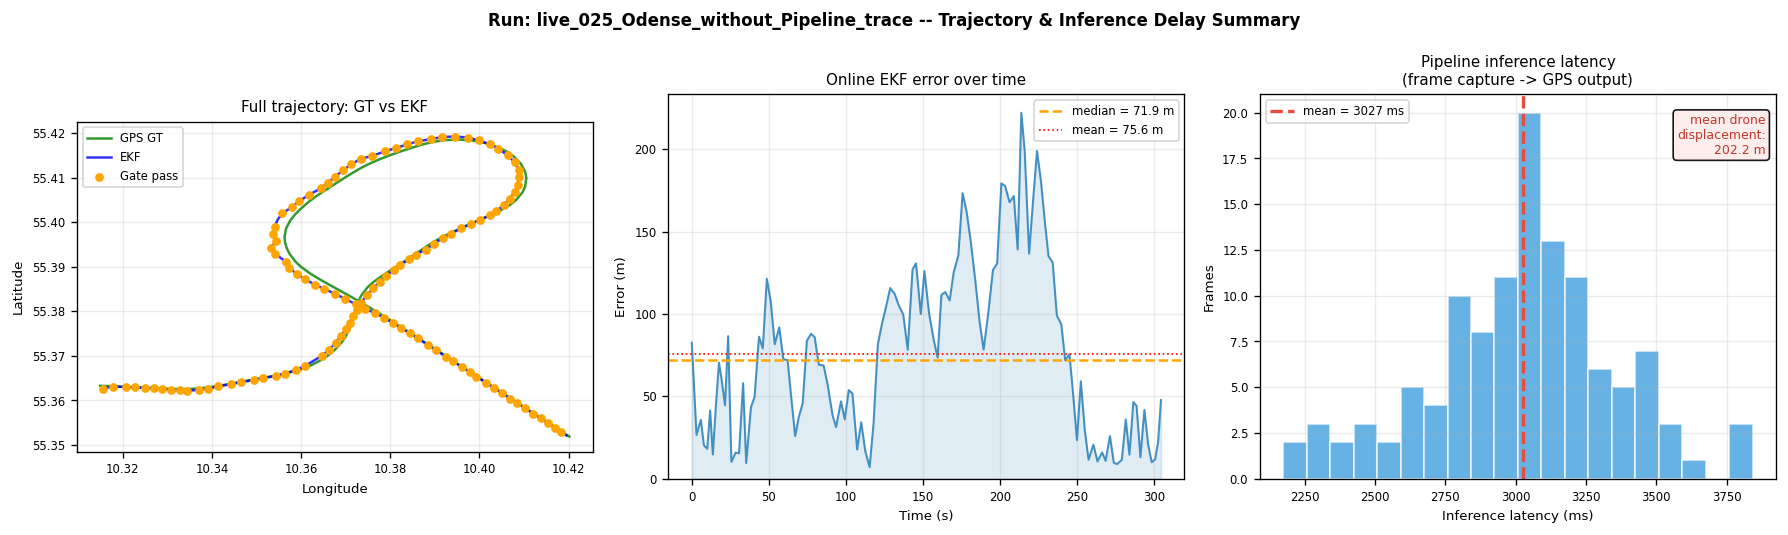

In [60]:
# Cell 15 — Trajectory GIF with Inference Delay Visualisation
#
# Shows the lag between drone position and pipeline GPS output.
# Layout per GIF frame:
#   Left (wide):  GT trail (green dashes) + EKF trail (blue)
#                 GT at capture (^ green)  EKF output (blue)  drone actual position at output time (red diamond)
#                 Red arrow + distance label = how far drone moved during inference.
#   Top-right:    per-frame numbers (inference ms, lag distance, error, heading).
#   Bottom bar:   timeline — capture tick, shaded inference window, output tick,
#                 "drone moved Xm" annotation.
#
# Also saves a static 3-panel summary PNG.
# Requires: pip install imageio

try:
    import imageio
except ImportError:
    print("imageio not installed — run: pip install imageio\nSkipping.")
    imageio = None

if imageio is not None:
    import matplotlib
    matplotlib.use("Agg")
    from matplotlib.backends.backend_agg import FigureCanvasAgg

    GIF_FPS    = 5
    MAX_FRAMES = len(results)

    ts_arr   = results["timestamp"].values
    lons_ekf = results["final_lon"].values
    lats_ekf = results["final_lat"].values
    lons_gt  = results["gps_lon"].values
    lats_gt  = results["gps_lat"].values
    errs     = results["online_err_m"].values
    methods  = results["method"].values
    gates    = results["gate_pass"].astype(bool).values
    inf_ms   = results["inference_ms"].values       # ms: capture -> GPS output
    hdg      = results["heading_deg"].values

    # ── Where the drone is when the GPS estimate is delivered ─────────────
    valid_gt = ~np.isnan(lats_gt)
    gt_out_lat = np.full(MAX_FRAMES, np.nan)
    gt_out_lon = np.full(MAX_FRAMES, np.nan)
    if valid_gt.sum() > 1:
        ts_v   = ts_arr[valid_gt]
        lat_v  = lats_gt[valid_gt]
        lon_v  = lons_gt[valid_gt]
        out_ts = ts_arr + inf_ms / 1000.0
        gt_out_lat = np.interp(out_ts, ts_v, lat_v, left=lat_v[0],  right=lat_v[-1])
        gt_out_lon = np.interp(out_ts, ts_v, lon_v, left=lon_v[0], right=lon_v[-1])
        for i in range(MAX_FRAMES):
            if not valid_gt[i]:
                gt_out_lat[i] = gt_out_lon[i] = np.nan

    # Metres the drone covered during inference
    lag_m = np.array([
        _hav(lats_gt[i], lons_gt[i], gt_out_lat[i], gt_out_lon[i])
        if (valid_gt[i] and not np.isnan(gt_out_lat[i])) else np.nan
        for i in range(MAX_FRAMES)
    ])

    # ── Axis limits ───────────────────────────────────────────────────────
    all_lons = np.concatenate([lons_ekf, lons_gt[valid_gt],
                                gt_out_lon[~np.isnan(gt_out_lon)]])
    all_lats = np.concatenate([lats_ekf, lats_gt[valid_gt],
                                gt_out_lat[~np.isnan(gt_out_lat)]])
    lon_pad = (all_lons.max() - all_lons.min()) * 0.10 + 1e-5
    lat_pad = (all_lats.max() - all_lats.min()) * 0.10 + 1e-5
    lon_lim = (all_lons.min() - lon_pad, all_lons.max() + lon_pad)
    lat_lim = (all_lats.min() - lat_pad, all_lats.max() + lat_pad)
    t_rel   = ts_arr - ts_arr[0]

    mean_lag = np.nanmean(lag_m)
    mean_inf = np.nanmean(inf_ms)
    print(f"Generating delay-aware GIF  ({MAX_FRAMES} frames @ {GIF_FPS} fps)")
    print(f"Mean inference latency : {mean_inf:.0f} ms")
    print(f"Mean drone displacement during inference: {mean_lag:.1f} m")

    gif_frames = []

    for i in range(MAX_FRAMES):
        fig = plt.figure(figsize=(14, 6))
        gs  = fig.add_gridspec(2, 3,
                               height_ratios=[4.2, 1.4],
                               width_ratios=[1.6, 1.6, 1.0],
                               hspace=0.38, wspace=0.28)
        ax_map  = fig.add_subplot(gs[0, :2])
        ax_info = fig.add_subplot(gs[0, 2])
        ax_bar  = fig.add_subplot(gs[1, :])

        # ── Map ───────────────────────────────────────────────────────────
        v = ~np.isnan(lats_gt[:i+1])
        if v.sum() > 1:
            ax_map.plot(lons_gt[:i+1][v], lats_gt[:i+1][v],
                        "g--", lw=1.3, alpha=0.55, label="GPS ground truth", zorder=2)
        ax_map.plot(lons_ekf[:i+1], lats_ekf[:i+1],
                    color="#2980b9", lw=1.8, alpha=0.85,
                    label="EKF estimate (pipeline output)", zorder=3)
        if valid_gt[i]:
            ax_map.scatter(lons_gt[i], lats_gt[i], c="#27ae60", s=80, marker="^",
                           zorder=5, edgecolors="white", lw=1.2,
                           label="GT at capture time")
        ax_map.scatter(lons_ekf[i], lats_ekf[i], c="#2980b9", s=100,
                       zorder=6, edgecolors="white", lw=1.5,
                       label="EKF output position")
        if gates[i]:
            ax_map.scatter(lons_ekf[i], lats_ekf[i], s=220, facecolors="none",
                           edgecolors="#f39c12", lw=2, zorder=7)
        # Red: where drone ACTUALLY IS when GPS output arrives
        if not np.isnan(gt_out_lat[i]):
            ax_map.scatter(gt_out_lon[i], gt_out_lat[i], c="#e74c3c", s=90,
                           marker="D", zorder=8, edgecolors="white", lw=1.2,
                           label=f"Drone at output time (+{inf_ms[i]:.0f} ms)")
            ax_map.annotate(
                "", xy=(gt_out_lon[i], gt_out_lat[i]),
                xytext=(lons_ekf[i], lats_ekf[i]),
                arrowprops=dict(arrowstyle="-|>", color="#e74c3c", lw=1.8,
                                connectionstyle="arc3,rad=0.18"), zorder=9)
            if not np.isnan(lag_m[i]) and lag_m[i] > 2:
                mx = (lons_ekf[i] + gt_out_lon[i]) / 2
                my = (lats_ekf[i] + gt_out_lat[i]) / 2
                ax_map.text(mx, my, f"+{lag_m[i]:.0f} m",
                            fontsize=7.5, color="#c0392b", fontweight="bold",
                            ha="center", va="center",
                            bbox=dict(fc="white", alpha=0.75,
                                      boxstyle="round,pad=0.2"), zorder=10)

        ax_map.set_xlim(*lon_lim); ax_map.set_ylim(*lat_lim)
        ax_map.set_xlabel("Longitude", fontsize=8)
        ax_map.set_ylabel("Latitude",  fontsize=8)
        ax_map.tick_params(labelsize=7); ax_map.grid(alpha=0.2)
        err_s = f"{errs[i]:.0f} m" if not np.isnan(errs[i]) else "N/A"
        ax_map.set_title(
            f"F{i:03d}  |  {methods[i]}  |  gate={'PASS' if gates[i] else 'fail'}  |  err={err_s}",
            fontsize=9, fontweight="bold")
        ax_map.legend(fontsize=6.5, loc="upper left", framealpha=0.88)

        # ── Info panel ────────────────────────────────────────────────────
        ax_info.axis("off")
        lag_s  = f"{lag_m[i]:.1f} m" if not np.isnan(lag_m[i]) else "N/A"
        lag_hi = not np.isnan(lag_m[i]) and lag_m[i] > 50
        info_rows = [
            ("Frame",          f"{i} / {MAX_FRAMES-1}"),
            ("Elapsed",        f"{t_rel[i]:.1f} s"),
            ("Inference",      f"{inf_ms[i]:.0f} ms"),
            ("Drone moved\nduring inference", lag_s),
            ("EKF sigma",      f"{results['ekf_pos_sigma'].iloc[i]:.1f} m"),
            ("Heading",        f"{hdg[i]:.1f} deg"),
            ("Error",          err_s),
        ]
        for k, (lbl, val) in enumerate(info_rows):
            y = 0.97 - k * 0.135
            ax_info.text(0.05, y, lbl, fontsize=7.5, va="top",
                         color="#888", transform=ax_info.transAxes)
            col = ("#c0392b" if k == 3 and lag_hi else "#111")
            ax_info.text(0.05, y - 0.06, val, fontsize=8.5, va="top",
                         fontweight="bold", color=col,
                         transform=ax_info.transAxes)
        ax_info.set_title("Frame info", fontsize=8.5, pad=4)

        # ── Timeline bar ──────────────────────────────────────────────────
        delay_s = inf_ms[i] / 1000.0
        ax_bar.set_xlim(max(0, t_rel[i] - 5), t_rel[i] + 4 * delay_s + 1.5)
        ax_bar.set_ylim(-0.6, 1.8)
        ax_bar.axis("off")
        ax_bar.axhline(0.5, color="#ccc", lw=1, zorder=1)
        for j in range(max(0, i - 6), i):
            ax_bar.scatter(t_rel[j], 0.5, c="#bbb", s=12, zorder=2)
        # Capture tick (green)
        ax_bar.scatter(t_rel[i], 0.5, c="#27ae60", s=60, marker="|",
                       linewidths=3, zorder=5)
        ax_bar.text(t_rel[i], 1.45, f"Frame captured\nt={t_rel[i]:.1f}s",
                    fontsize=6.5, ha="center", va="top", color="#27ae60")
        # Inference window
        ax_bar.axvspan(t_rel[i], t_rel[i] + delay_s, ymin=0.25, ymax=0.75,
                       color="#fdecea", alpha=0.8, zorder=3)
        ax_bar.text((t_rel[i] + t_rel[i] + delay_s) / 2, 0.5,
                    f"{inf_ms[i]:.0f} ms", fontsize=6.5,
                    ha="center", va="center", color="#999", style="italic")
        # Output tick (red)
        out_t = t_rel[i] + delay_s
        ax_bar.scatter(out_t, 0.5, c="#e74c3c", s=60, marker="|",
                       linewidths=3, zorder=5)
        ax_bar.text(out_t, 1.45, f"GPS output\nt={out_t:.1f}s",
                    fontsize=6.5, ha="center", va="top", color="#e74c3c")
        if not np.isnan(lag_m[i]):
            ax_bar.annotate(
                f"drone moved {lag_m[i]:.0f} m\nduring inference",
                xy=(out_t, 0.5), xytext=(out_t + 0.3, -0.3),
                fontsize=6.5, color="#c0392b",
                arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.8))
        lag_str = f"   |   drone flew {lag_m[i]:.0f} m in that time" if not np.isnan(lag_m[i]) else ""
        ax_bar.set_title(
            f"Pipeline latency: capture  ->  {inf_ms[i]:.0f} ms inference  ->  GPS output{lag_str}",
            fontsize=7.5, color="#555", pad=2)

        fig.suptitle(
            "Inference Delay:  GT at capture (^ green)  .  EKF output (blue)  .  Drone at output time (red diamond)\n"
            "Red arrow = position the drone has already moved past by the time the pipeline responds",
            fontsize=8.5, fontweight="bold")

        canvas = FigureCanvasAgg(fig)
        canvas.draw()
        gif_frames.append(np.asarray(canvas.buffer_rgba())[:, :, :3])
        plt.close(fig)

    gif_path = OUT_DIR / f"{meta.get('run_id', RUN_DIR.name)}_delay_trajectory.gif"
    imageio.mimsave(str(gif_path), gif_frames, fps=GIF_FPS)
    print(f"\nSaved GIF -> {gif_path}  ({len(gif_frames)} frames)")

    # ── Static 3-panel summary PNG ────────────────────────────────────────
    matplotlib.use("inline")
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.5))

    v = ~np.isnan(lats_gt)
    axes2[0].plot(lons_gt[v], lats_gt[v], "g-", lw=1.5, label="GPS GT", alpha=0.8)
    axes2[0].plot(lons_ekf, lats_ekf, "b-", lw=1.5, label="EKF", alpha=0.8)
    axes2[0].scatter(lons_ekf[gates & v], lats_ekf[gates & v],
                     c="orange", s=18, zorder=5, label="Gate pass")
    axes2[0].set_title("Full trajectory: GT vs EKF", fontsize=9)
    axes2[0].legend(fontsize=7); axes2[0].set_aspect("equal")
    axes2[0].grid(alpha=0.25); axes2[0].tick_params(labelsize=7)
    axes2[0].set_xlabel("Longitude", fontsize=8); axes2[0].set_ylabel("Latitude", fontsize=8)

    ve = ~np.isnan(errs)
    axes2[1].plot(t_rel[ve], errs[ve], color="#2980b9", lw=1.2, alpha=0.85)
    axes2[1].fill_between(t_rel[ve], 0, errs[ve], alpha=0.15, color="#2980b9")
    axes2[1].axhline(np.nanmedian(errs), color="orange", lw=1.5, ls="--",
                     label=f"median = {np.nanmedian(errs):.1f} m")
    axes2[1].axhline(np.nanmean(errs), color="red", lw=1, ls=":",
                     label=f"mean = {np.nanmean(errs):.1f} m")
    axes2[1].set_xlabel("Time (s)", fontsize=8); axes2[1].set_ylabel("Error (m)", fontsize=8)
    axes2[1].set_title("Online EKF error over time", fontsize=9)
    axes2[1].legend(fontsize=7); axes2[1].grid(alpha=0.25)
    axes2[1].tick_params(labelsize=7); axes2[1].set_ylim(bottom=0)

    axes2[2].hist(inf_ms, bins=20, color="#3498db", alpha=0.75, edgecolor="white")
    axes2[2].axvline(mean_inf, color="#e74c3c", lw=2, ls="--",
                     label=f"mean = {mean_inf:.0f} ms")
    axes2[2].set_xlabel("Inference latency (ms)", fontsize=8)
    axes2[2].set_ylabel("Frames", fontsize=8)
    axes2[2].set_title("Pipeline inference latency\n(frame capture -> GPS output)", fontsize=9)
    axes2[2].legend(fontsize=7); axes2[2].grid(alpha=0.25)
    axes2[2].tick_params(labelsize=7)
    axes2[2].text(0.98, 0.95,
                  f"mean drone\ndisplacement:\n{mean_lag:.1f} m",
                  transform=axes2[2].transAxes, fontsize=7.5,
                  va="top", ha="right", color="#c0392b",
                  bbox=dict(boxstyle="round,pad=0.3", fc="#fdecea", alpha=0.9))

    fig2.suptitle(
        f"Run: {meta.get('run_id', RUN_DIR.name)} -- Trajectory & Inference Delay Summary",
        fontsize=10, fontweight="bold")
    plt.tight_layout()
    if SAVE_FIGS:
        static_path = OUT_DIR / f"{meta.get('run_id', RUN_DIR.name)}_delay_summary.png"
        fig2.savefig(str(static_path), dpi=130, bbox_inches="tight")
        print(f"Static summary -> {static_path}")
    plt.show()